In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("default")

In [6]:
import os

print(os.getcwd())

C:\Users\nandi


In [11]:
import os

os.chdir(
    r"C:\Users\nandi\OneDrive\Desktop\mutual_fund_analysis"
)

print(os.getcwd())

C:\Users\nandi\OneDrive\Desktop\mutual_fund_analysis


In [12]:
import pandas as pd

fund = pd.read_csv("data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("data/processed/nav_history_clean.csv")

perf = pd.read_csv("data/processed/scheme_performance_clean.csv")

tx = pd.read_csv("data/processed/investor_transactions_clean.csv")

aum = pd.read_csv("data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("data/processed/06_industry_folio_count_clean.csv")

holdings = pd.read_csv("data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [13]:
print(fund.shape)
print(nav.shape)
print(tx.shape)

(40, 15)
(46000, 3)
(32778, 13)


In [14]:
print(aum.columns.tolist())
print(sip.columns.tolist())
print(category.columns.tolist())
print(folio.columns.tolist())
print(holdings.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
['month', 'category', 'net_inflow_crore']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


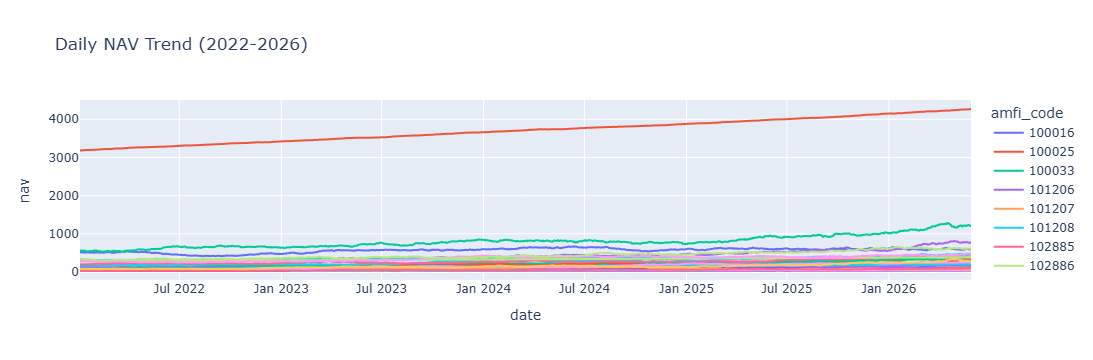

In [15]:
import plotly.express as px

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

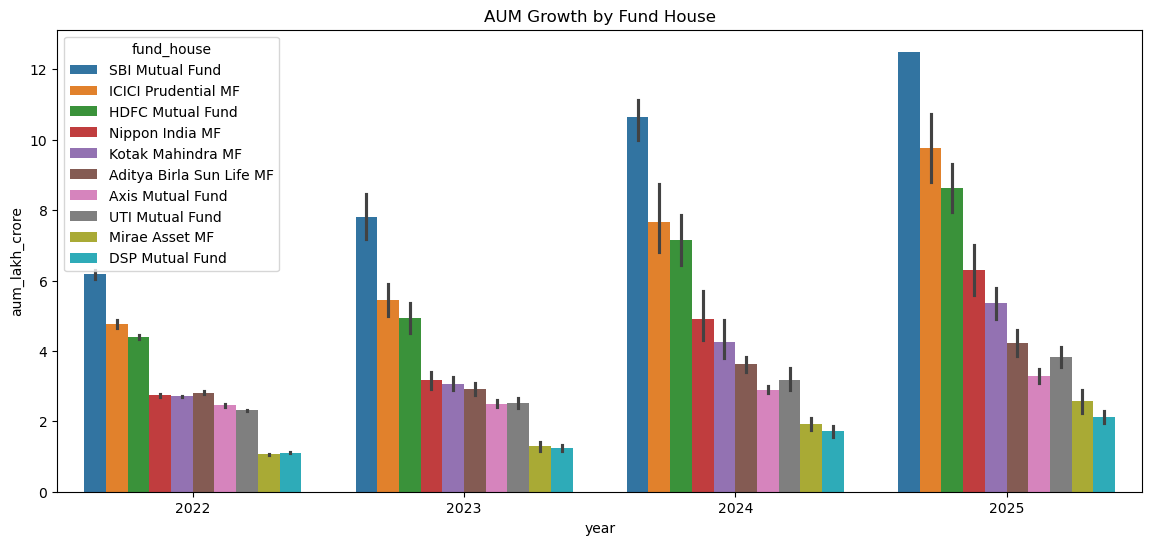

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

aum["year"] = pd.to_datetime(aum["date"]).dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.show()

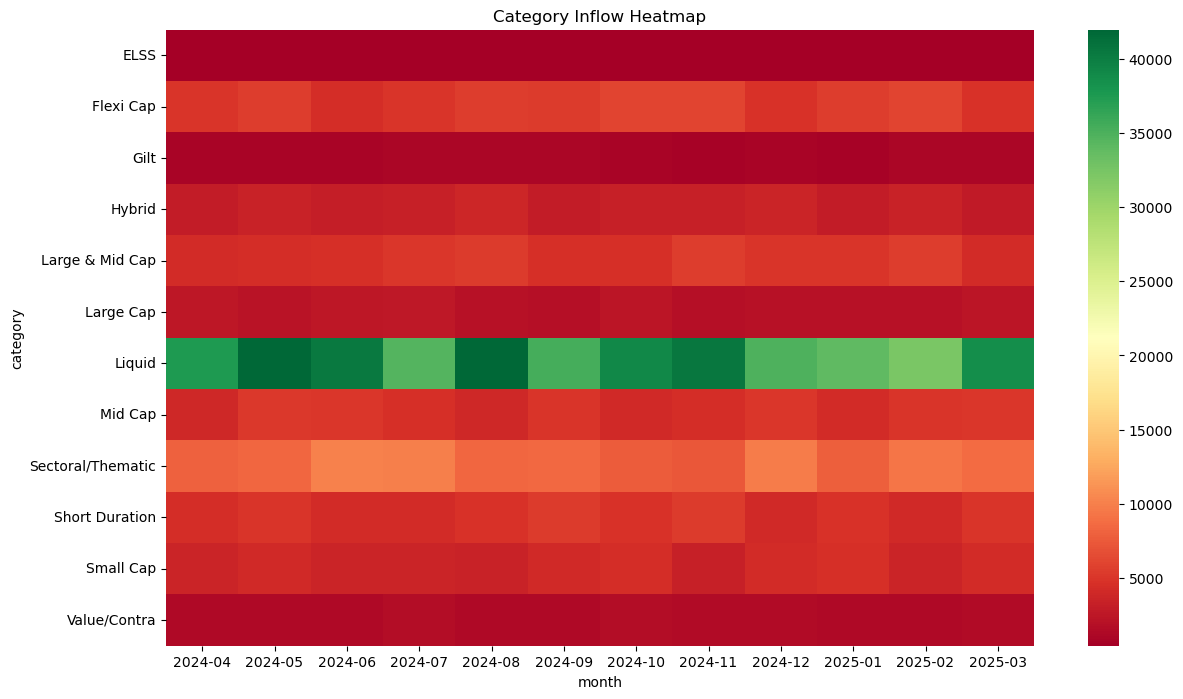

In [17]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn"
)

plt.title("Category Inflow Heatmap")

plt.show()

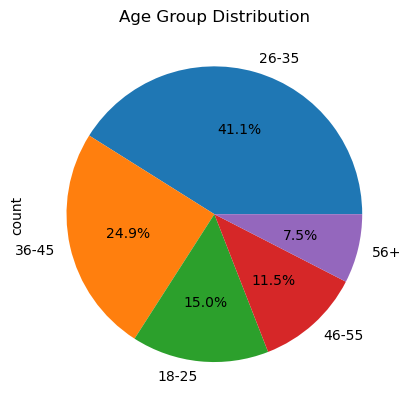

In [18]:
tx["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.show()

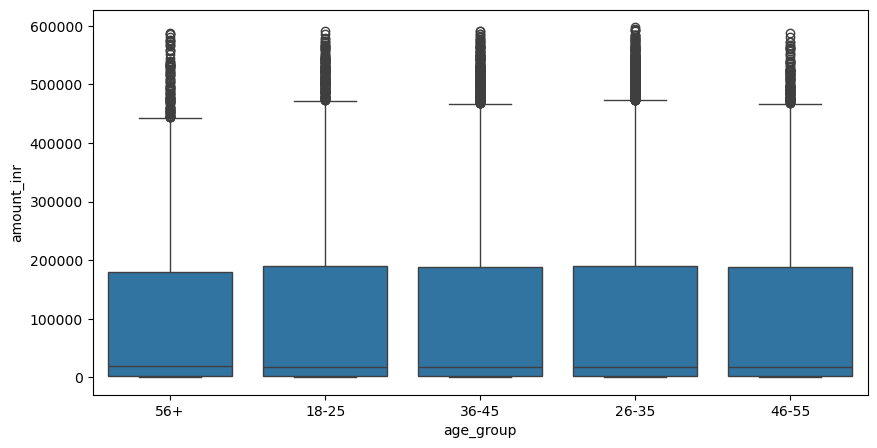

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=tx,
    x="age_group",
    y="amount_inr"
)

plt.show()

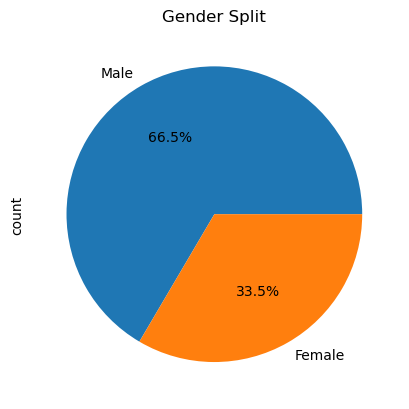

In [20]:
tx["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Gender Split")

plt.show()

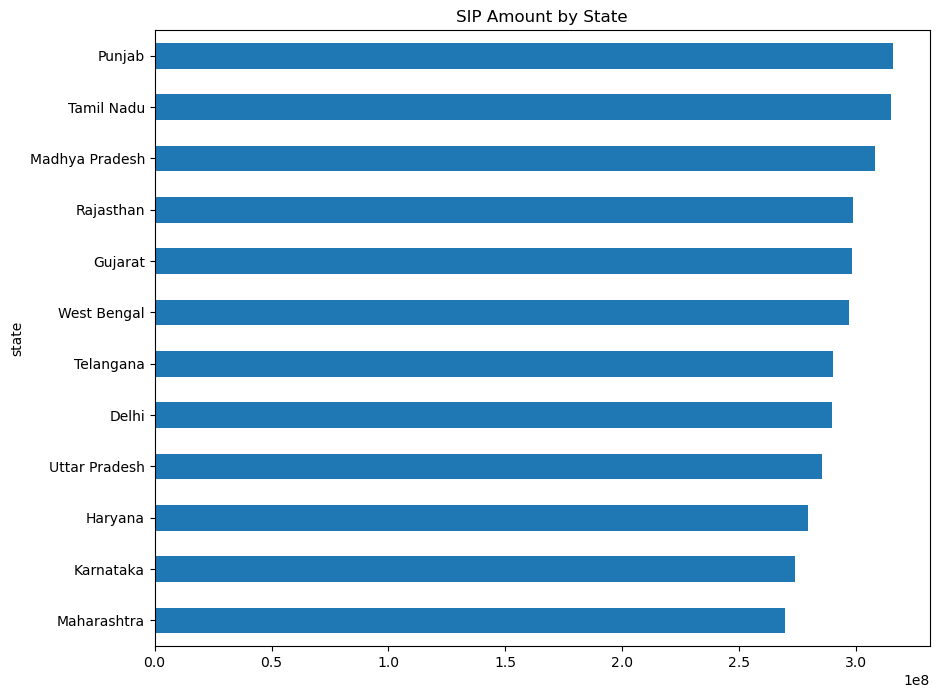

In [21]:
state_data = (
    tx.groupby("state")
      ["amount_inr"]
      .sum()
      .sort_values()
)

state_data.plot.barh(figsize=(10,8))

plt.title("SIP Amount by State")

plt.show()

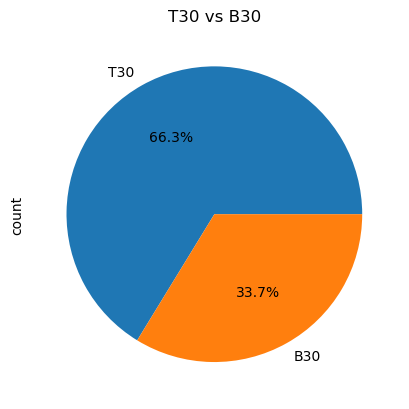

In [22]:
tx["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("T30 vs B30")

plt.show()

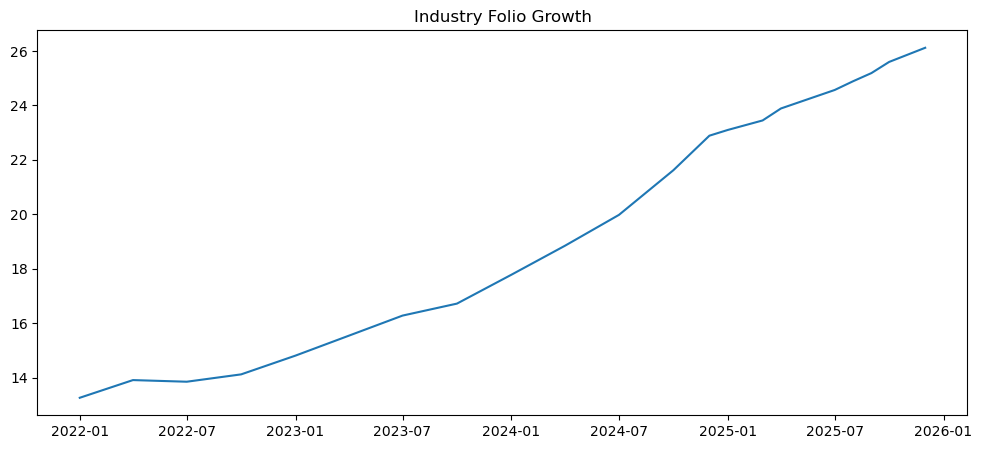

In [23]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.show()

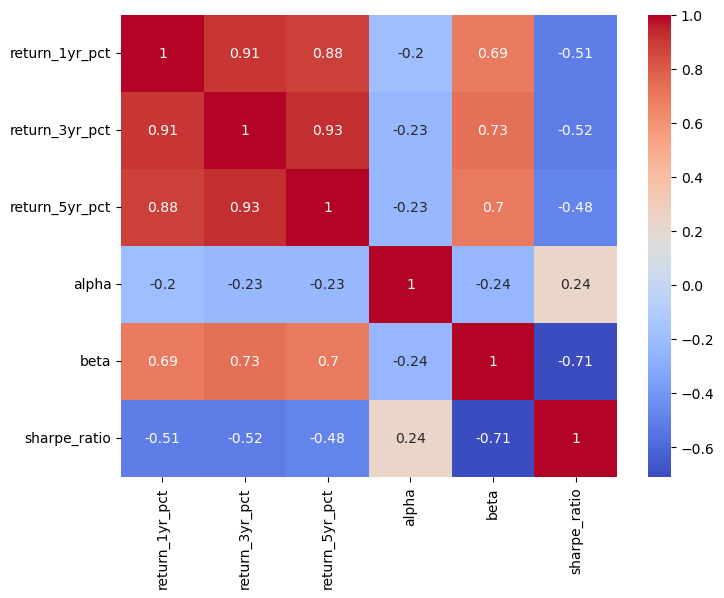

In [24]:
corr = perf[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

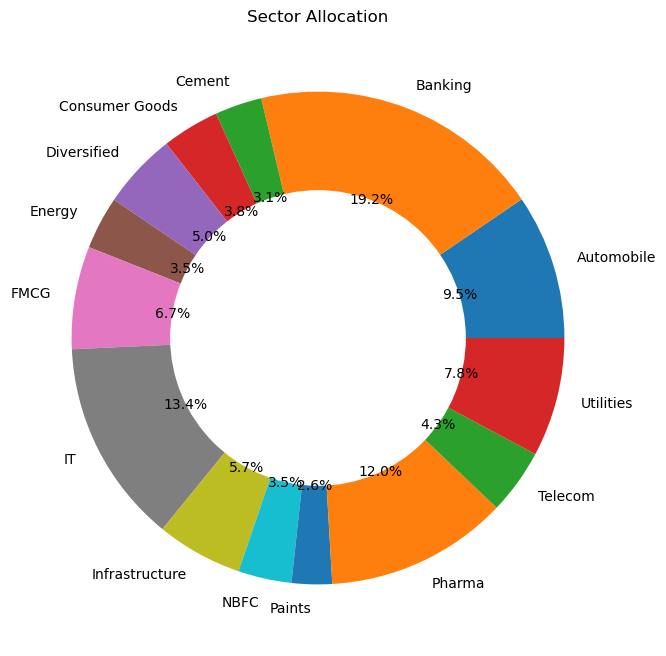

In [26]:
sector = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre = plt.Circle(
    (0,0),
    0.60,
    fc="white"
)

plt.gca().add_artist(
    centre
)

plt.title(
    "Sector Allocation"
)

plt.show()

# Key EDA Findings

1. **NAV values showed a long-term upward trend across most mutual fund schemes.**

2. **SBI Mutual Fund consistently maintained one of the highest AUM levels.**

3. **SIP inflows increased significantly between 2022 and 2025.**

4. **Equity-oriented categories attracted the highest investor inflows.**

5. **The 26–35 age group contributed the largest share of transactions.**

6. **Male investors accounted for a higher transaction volume than female investors.**

7. **T30 cities generated more SIP investment activity than B30 cities.**

8. **Total industry folios nearly doubled during the study period.**

9. **Fund returns and Sharpe ratios displayed positive correlations.**

10. **Financial Services and Technology sectors occupied a major share of portfolio allocations.**